# Sentinel-2 Vegetation Indices — DE-Har 2025

## Data source

Uses the same `sentle` weekly-composite zarr as the S1 notebook:
`/mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr`

All indices computed via **spyndex** (Montero et al. 2023, doi:10.1038/s41597-023-02096-0) —
same implementation as `notebooks/02_analysis/EGU/time_series.ipynb`.
kNDVI uses the proper RBF kernel via `spyndex.computeKernel`, not the simplified tanh(NDVI²).

## Spyndex band → zarr band mapping

| spyndex param | zarr band | wavelength |
|---|---|---|
| B  | B02 | 490 nm (Blue) |
| G  | B03 | 560 nm (Green) |
| R  | B04 | 665 nm (Red) |
| RE1 | B05 | 705 nm (Red Edge 1) |
| RE2 | B06 | 740 nm (Red Edge 2) |
| RE3 | B07 | 783 nm (Red Edge 3) |
| N  | B08 | 842 nm (NIR broad) |
| N2 | B8A | 865 nm (NIR narrow) |
| S1 | B11 | 1610 nm (SWIR 1) |

Scale: the zarr stores values in **GEE SR scale (0–10 000)** — auto-detected and normalised to 0–1 before index computation.

## Processing chain

```
zarr (S2 SR, weekly composites, 0-10000 scale)
 → select all needed bands
 → crop to field-site ROI  (same bbox as S1 notebook)
 → normalise to 0-1 (÷10000 if max > 2)
 → compute kNDVI RBF kernel via spyndex.computeKernel
 → compute all indices via spyndex  (pixel-wise, catalogue constants auto-filled)
 → aggregate: mean + std across ROI pixels → 1-D time series
 → Savitzky-Golay on mean and std
 → plots + CSV export
```

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import xarray as xr
import spyndex
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})

PROJECT_ROOT = Path().resolve().parents[1]
OUT_CSV      = PROJECT_ROOT / 'data/processed/satellite/sentinel2_filtered_2025.csv'

## Parameters

In [3]:
ZARR_PATH = Path('/mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr')

# ── ROI — same field-site bbox as S1 notebook ─────────────────────────────────
SITE_LEFT   = 395304.3125
SITE_BOTTOM = 5309842.5
SITE_RIGHT  = 395373.5
SITE_TOP    = 5309912.5

# ── Savitzky-Golay (applied on aggregated 1-D time series) ────────────────────
SAVGOL_WINDOW = 5   # must be odd
SAVGOL_POLY   = 2

EXPORT_VARS = ['NDVI', 'kNDVI', 'EVI', 'NIRv', 'SAVI', 'CIRE', 'MTCI', 'NDII']

## Helper — SavGol with NaN handling

In [4]:
def apply_savgol(df: pd.DataFrame) -> pd.DataFrame:
    """Apply Savitzky-Golay to each column, skipping NaN gaps."""
    out = df.copy()
    for col in out.columns:
        valid = ~np.isnan(out[col])
        if valid.sum() >= SAVGOL_WINDOW:
            out.loc[valid, col] = savgol_filter(
                out.loc[valid, col].values,
                window_length=SAVGOL_WINDOW,
                polyorder=SAVGOL_POLY,
            )
    return out

## Load data

In [5]:
print(f'Loading: {ZARR_PATH}')
ds_z = xr.open_zarr(ZARR_PATH, chunks={})
da   = ds_z['sentle']

x_coords = ds_z.x.values
y_coords = ds_z.y.values
times    = pd.to_datetime(sorted(ds_z.time.values))

print(f'Grid: {len(x_coords)}x{len(y_coords)} px @ {x_coords[1]-x_coords[0]:.0f} m')
print(f'Scenes: {len(times)},  {times[0].date()} - {times[-1].date()}')
print(f'Bands: {list(ds_z.band.values)}')

# Select all S2 bands needed for the indices
# zarr uses B02/B03/... notation with leading zeros; B8A is the exception
b02 = da.sel(band='B02').sortby('time')   # Blue   490 nm
b03 = da.sel(band='B03').sortby('time')   # Green  560 nm
b04 = da.sel(band='B04').sortby('time')   # Red    665 nm
b05 = da.sel(band='B05').sortby('time')   # RE1    705 nm
b06 = da.sel(band='B06').sortby('time')   # RE2    740 nm
b07 = da.sel(band='B07').sortby('time')   # RE3    783 nm
b08 = da.sel(band='B08').sortby('time')   # NIR    842 nm
b8a = da.sel(band='B8A').sortby('time')   # NIR-n  865 nm
b11 = da.sel(band='B11').sortby('time')   # SWIR1  1610 nm

Loading: /mnt/data/lk1167/projects/other/data/icos-har/processed/sentinel/sentinel_har_2025.zarr
Grid: 100x100 px @ 10 m
Scenes: 48,  2025-01-02 - 2025-11-27
Bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'vh_asc', 'vh_desc', 'vv_asc', 'vv_desc']


## Crop to field-site ROI

In [6]:
def crop_roi(da):
    # y is descending in image coords → slice top to bottom
    return da.sel(x=slice(SITE_LEFT, SITE_RIGHT), y=slice(SITE_TOP, SITE_BOTTOM))

b02s = crop_roi(b02)
b03s = crop_roi(b03)
b04s = crop_roi(b04)
b05s = crop_roi(b05)
b06s = crop_roi(b06)
b07s = crop_roi(b07)
b08s = crop_roi(b08)
b8as = crop_roi(b8a)
b11s = crop_roi(b11)

n_pix = b04s.shape[1] * b04s.shape[2]
print(f'ROI crop: {b04s.shape}  ({n_pix} pixels)')
print(f'X: {float(b04s.x.min()):.1f} - {float(b04s.x.max()):.1f} m')
print(f'Y: {float(b04s.y.min()):.1f} - {float(b04s.y.max()):.1f} m')

ROI crop: (48, 7, 7)  (49 pixels)
X: 395310.0 - 395370.0 m
Y: 5309850.0 - 5309910.0 m


## Load, scale-normalise, compute kNDVI kernel, compute indices via spyndex

In [7]:
print('Loading ROI bands into memory ...')
b02s = b02s.load().astype('float32')
b03s = b03s.load().astype('float32')
b04s = b04s.load().astype('float32')
b05s = b05s.load().astype('float32')
b06s = b06s.load().astype('float32')
b07s = b07s.load().astype('float32')
b08s = b08s.load().astype('float32')
b8as = b8as.load().astype('float32')
b11s = b11s.load().astype('float32')
print('  done')

# Scale normalisation: GEE SR = 0-10000, sentle may differ
# Use nanmax (not a single scene) so a cloud-masked scene can't fool the check
sc = 10000.0
b04_max = float(np.nanmax(b04s.values))
print(f'B04 nanmax: {b04_max:.1f}')
if b04_max > 2.0:
    b02s, b03s, b04s = b02s/sc, b03s/sc, b04s/sc
    b05s, b06s, b07s = b05s/sc, b06s/sc, b07s/sc
    b08s, b8as, b11s = b08s/sc, b8as/sc, b11s/sc
    print(f'  -> divided by {sc:.0f}  (GEE scale detected)')
else:
    print('  -> 0-1 reflectance (sentle scale, no conversion needed)')

# kNDVI RBF kernel — matches EGU time_series.ipynb
# sigma = median(|NIR - Red|) over the full ROI × time stack
sigma = float(np.nanmedian(np.abs(b08s.values - b04s.values)))
print(f'kNDVI RBF sigma: {sigma:.5f}')
kNR = spyndex.computeKernel(
    kernel='RBF',
    params={'a': b08s, 'b': b04s, 'sigma': sigma},
)

# Band parameter dict — spyndex name → cropped DataArray (0-1 scale)
band_params = {
    'N':   b08s,   # NIR broad      842 nm
    'N2':  b8as,   # NIR narrow     865 nm
    'R':   b04s,   # Red            665 nm
    'G':   b03s,   # Green          560 nm
    'B':   b02s,   # Blue           490 nm
    'RE1': b05s,   # Red Edge 1     705 nm
    'RE2': b06s,   # Red Edge 2     740 nm
    'RE3': b07s,   # Red Edge 3     783 nm
    'S1':  b11s,   # SWIR 1         1610 nm
    'kNN': 1.0,    # k(x,x) = 1 for RBF kernel
    'kNR': kNR,    # k(NIR, Red) — required for kNDVI
}

# Compute each index; spyndex auto-fills catalogue constants (L, g, c1, c2, ...)
indices = {}
for name in EXPORT_VARS:
    params = dict(band_params)
    for p in spyndex.indices[name].bands:
        if p not in params and p in spyndex.constants:
            params[p] = spyndex.constants[p].default
    indices[name] = spyndex.computeIndex(index=name, params=params, online=False)
    valid_pct = float(np.isfinite(indices[name].values).mean() * 100)
    print(f'  {name:6s}  mean={float(np.nanmean(indices[name].values)):.4f}  valid={valid_pct:.0f}%')

Loading ROI bands into memory ...
  done
B04 nanmax: 836.0
  -> divided by 10000  (GEE scale detected)
kNDVI RBF sigma: 0.20460
  NDVI    mean=0.7576  valid=50%
  kNDVI   mean=0.2830  valid=50%
  EVI     mean=0.4253  valid=50%
  NIRv    mean=0.1903  valid=50%
  SAVI    mean=0.3279  valid=50%
  CIRE    mean=2.3369  valid=50%
  MTCI    mean=2.6502  valid=50%
  NDII    mean=0.2415  valid=50%


## Aggregate to time series  +  Savitzky-Golay

In [8]:
time_index = pd.to_datetime(b04s.time.values)

# Spatial mean and std across ROI pixels
ts_mean = pd.DataFrame(
    {name: arr.mean(dim=['x', 'y']).values for name, arr in indices.items()},
    index=time_index,
).sort_index()

ts_std = pd.DataFrame(
    {name: arr.std(dim=['x', 'y']).values for name, arr in indices.items()},
    index=time_index,
).sort_index()

# Set 2025-09-04 to NaN
ts_mean.loc['2025-09-04'] = np.nan
ts_std.loc['2025-09-04'] = np.nan

# Savitzky-Golay applied on both mean and std
ts_savgol     = apply_savgol(ts_mean)
ts_savgol_std = apply_savgol(ts_std)

n_valid = (~ts_mean.isna()).sum()
print(f'{len(ts_mean)} time steps total, {n_pix} pixels')
print(f'Valid (non-NaN) scenes per index:')
print(n_valid.to_string())
print()
print(ts_mean.to_string())

48 time steps total, 49 pixels
Valid (non-NaN) scenes per index:
NDVI     24
kNDVI    24
EVI      24
NIRv     24
SAVI     24
CIRE     24
MTCI     24
NDII     24

                NDVI     kNDVI       EVI      NIRv      SAVI      CIRE      MTCI      NDII
2025-01-02       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-01-09       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-01-16  0.770911  0.084675  0.250301  0.104498  0.203933  2.271135  2.388681  0.248068
2025-01-23       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-01-30       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-02-06       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-02-13       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-02-20       NaN       NaN       NaN       NaN       NaN       NaN       NaN       NaN
2025-02-27       Na

## Plots — all indices with ±1 SD band

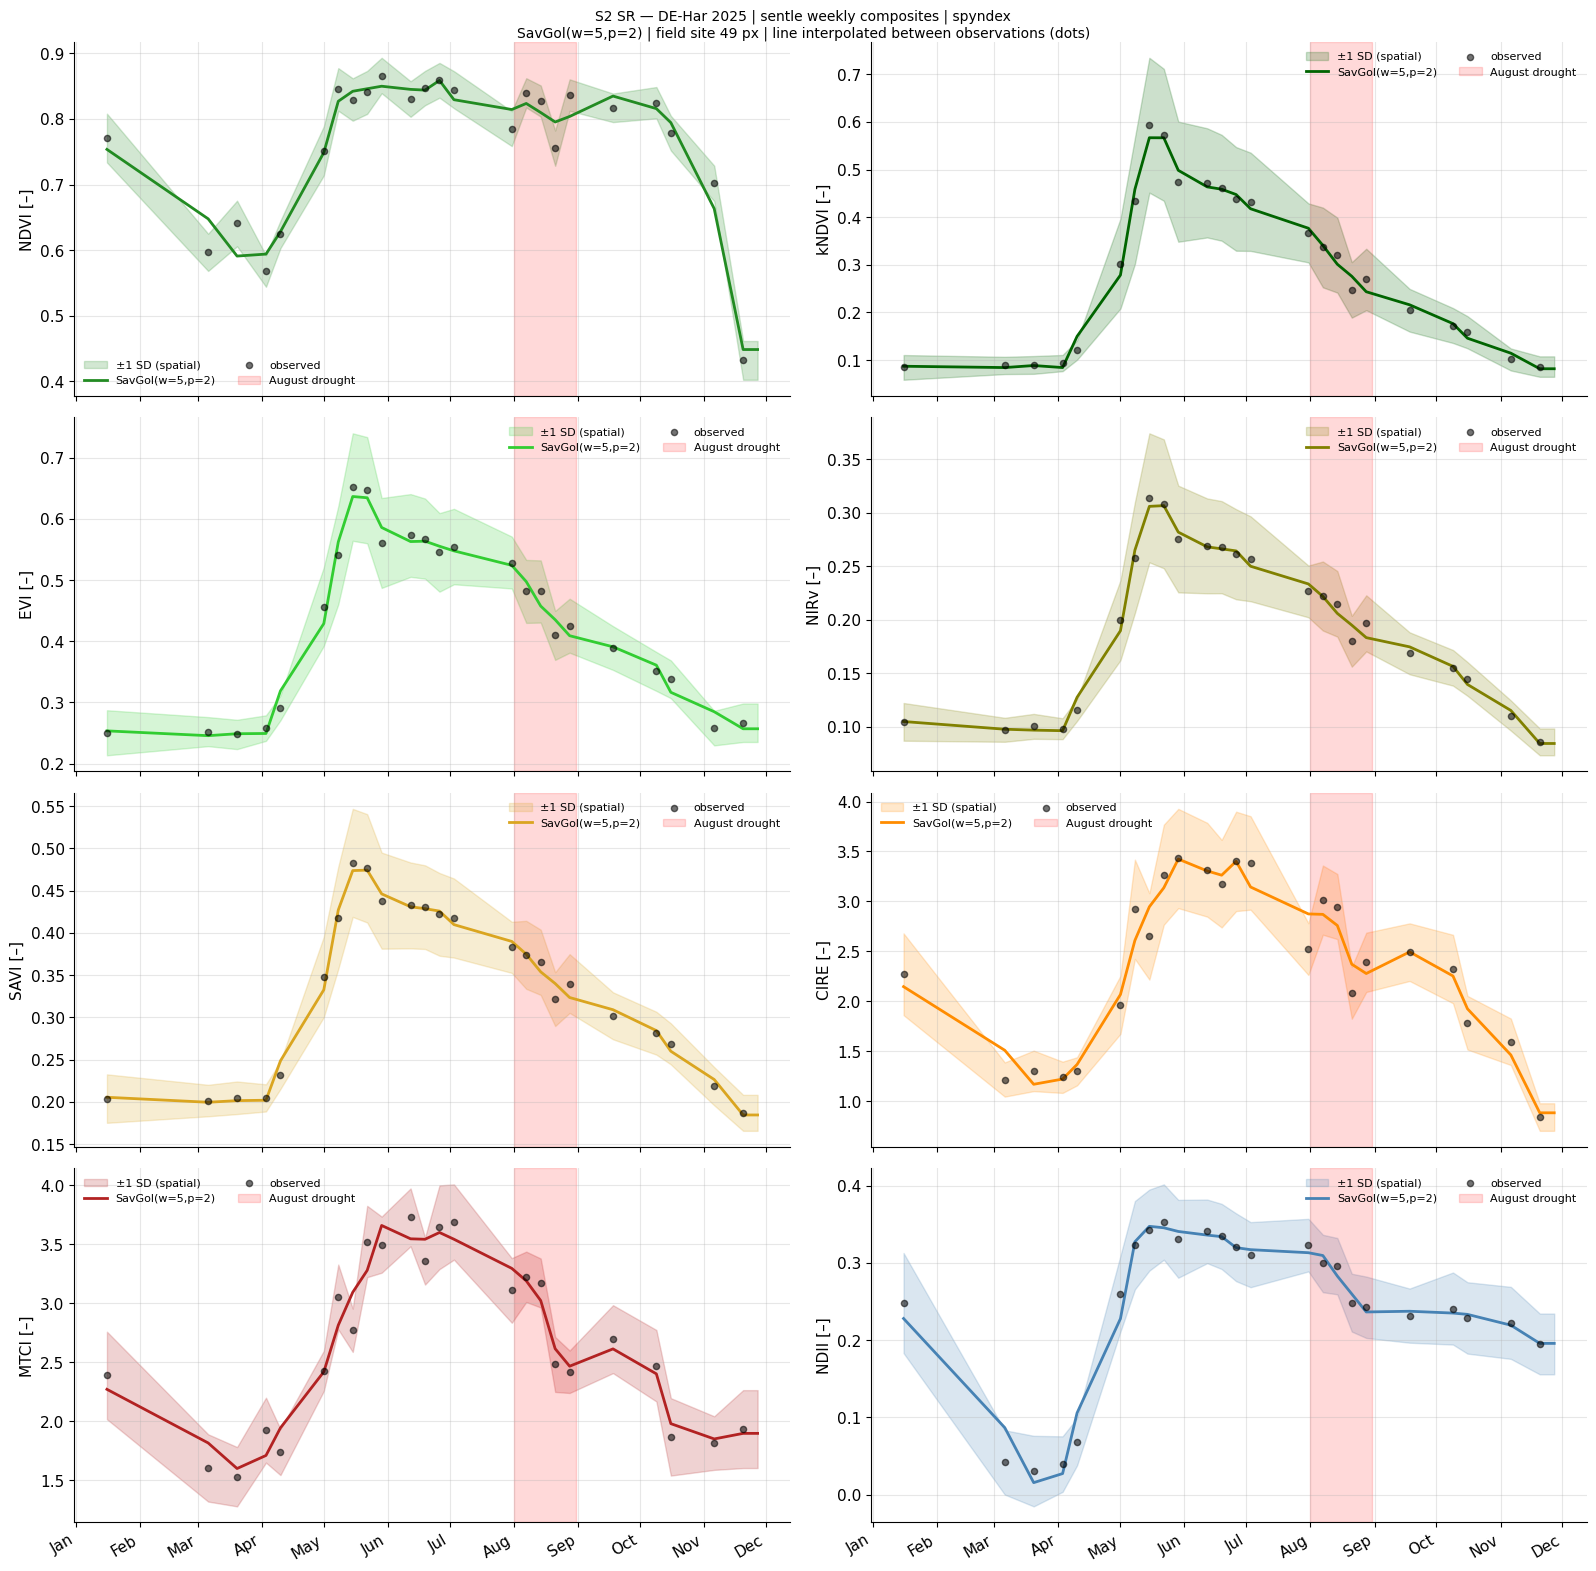

In [9]:
DROUGHT = (pd.Timestamp('2025-08-01'), pd.Timestamp('2025-08-31'))

PLOT_META = {
    'NDVI':  ('NDVI [–]',   'forestgreen'),
    'kNDVI': ('kNDVI [–]',  'darkgreen'),
    'EVI':   ('EVI [–]',    'limegreen'),
    'NIRv':  ('NIRv [–]',   'olive'),
    'SAVI':  ('SAVI [–]',   'goldenrod'),
    'CIRE':  ('CIRE [–]',   'darkorange'),
    'MTCI':  ('MTCI [–]',   'firebrick'),
    'NDII':  ('NDII [–]',   'steelblue'),
}

# Interpolate through cloud gaps for display only — export is unchanged
ts_mean_plt   = ts_mean.interpolate(method='time')
ts_savgol_plt = ts_savgol.interpolate(method='time')
ts_std_plt    = ts_std.interpolate(method='time')

fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=True)
axes_flat = axes.flatten()

for ax, (name, (ylabel, color)) in zip(axes_flat, PLOT_META.items()):
    obs_mask = ts_mean[name].notna()

    # Continuous SD envelope (interpolated)
    ax.fill_between(ts_mean_plt.index,
                    ts_mean_plt[name] - ts_std_plt[name],
                    ts_mean_plt[name] + ts_std_plt[name],
                    alpha=0.2, color=color, label='±1 SD (spatial)')

    # Continuous SavGol line (interpolated)
    ax.plot(ts_savgol_plt.index, ts_savgol_plt[name],
            '-', color=color, lw=2.0,
            label=f'SavGol(w={SAVGOL_WINDOW},p={SAVGOL_POLY})')

    # Observation dots — only at valid (non-cloud) scenes
    ax.scatter(ts_mean.index[obs_mask], ts_mean[name][obs_mask],
               s=20, color='black', zorder=5, alpha=0.55, label='observed')

    ax.axvspan(*DROUGHT, alpha=0.15, color='red', label='August drought')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, frameon=False, ncol=2)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

for ax in axes[-1, :]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(
    f'S2 SR — DE-Har 2025 | sentle weekly composites | spyndex\n'
    f'SavGol(w={SAVGOL_WINDOW},p={SAVGOL_POLY}) | field site {n_pix} px'
    f' | line interpolated between observations (dots)',
    fontsize=10,
)
fig.tight_layout()
plt.show()

## Drought check — August 2025

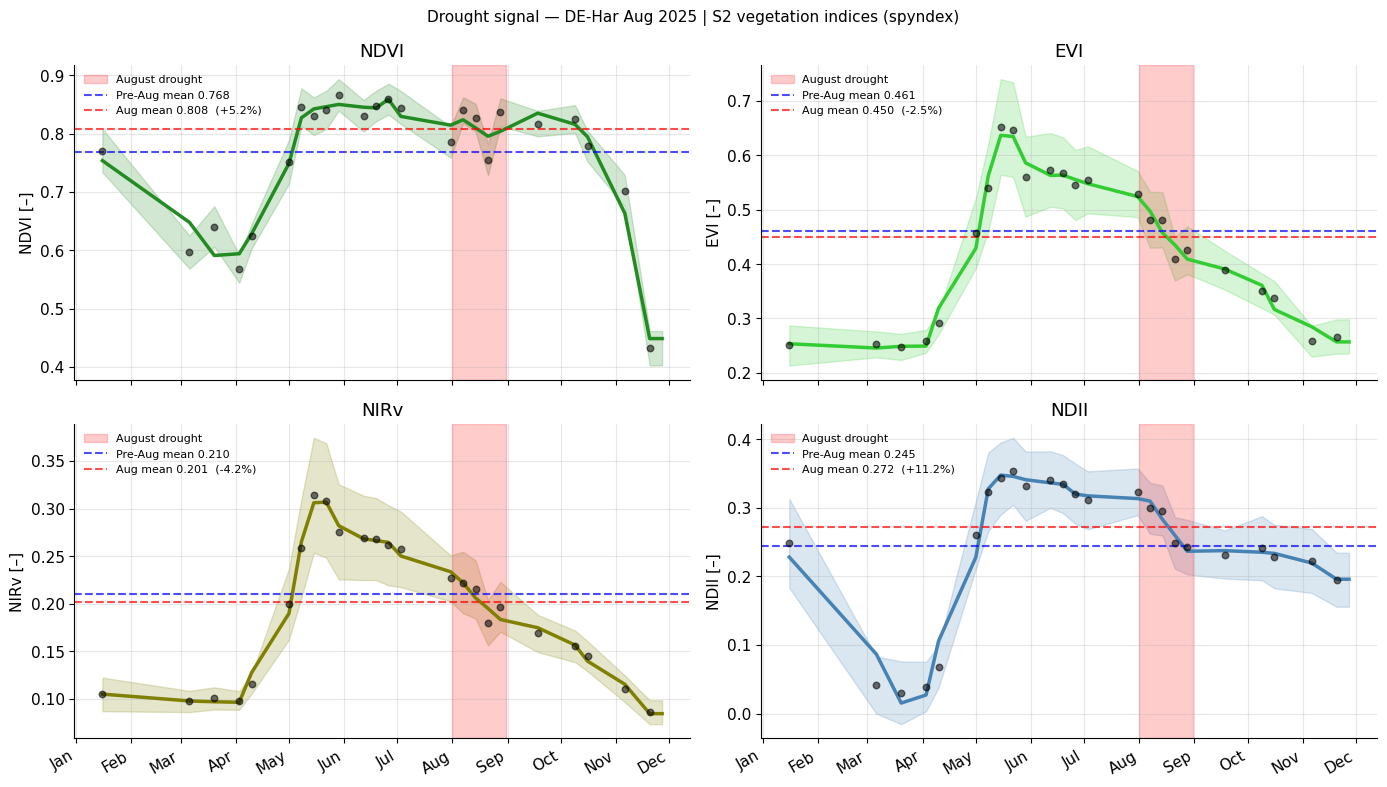

In [10]:
DROUGHT_VARS = ['NDVI', 'EVI', 'NIRv', 'NDII']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, col in zip(axes.flat, DROUGHT_VARS):
    color    = PLOT_META[col][1]
    pre_mask = ts_savgol.index < DROUGHT[0]
    aug_mask = (ts_savgol.index >= DROUGHT[0]) & (ts_savgol.index <= DROUGHT[1])
    obs_mask = ts_mean[col].notna()

    pre_mean = ts_savgol.loc[pre_mask, col].mean()
    aug_mean = ts_savgol.loc[aug_mask, col].mean()
    change   = (aug_mean - pre_mean) / abs(pre_mean) * 100 if pre_mean != 0 else float('nan')

    # Continuous SD envelope and SavGol line (interpolated)
    ax.fill_between(ts_mean_plt.index,
                    ts_mean_plt[col] - ts_std_plt[col],
                    ts_mean_plt[col] + ts_std_plt[col],
                    alpha=0.2, color=color)
    ax.plot(ts_savgol_plt.index, ts_savgol_plt[col], '-', color=color, lw=2.5)

    # Observation dots
    ax.scatter(ts_mean.index[obs_mask], ts_mean[col][obs_mask],
               s=22, color='black', zorder=5, alpha=0.55)

    ax.axvspan(*DROUGHT, alpha=0.2, color='red', label='August drought')
    ax.axhline(pre_mean, color='blue', ls='--', alpha=0.7,
               label=f'Pre-Aug mean {pre_mean:.3f}')
    ax.axhline(aug_mean, color='red',  ls='--', alpha=0.7,
               label=f'Aug mean {aug_mean:.3f}  ({change:+.1f}%)')
    ax.set_ylabel(PLOT_META[col][0])
    ax.set_title(col)
    ax.legend(fontsize=8, frameon=False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())

for ax in axes[-1, :]:
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('Drought signal — DE-Har Aug 2025 | S2 vegetation indices (spyndex)', fontsize=11)
fig.tight_layout()
plt.show()

## Export CSV

In [11]:
# Interpolated versions (same as used in plots — fill cloud gaps linearly in time)
ts_mean_interp       = ts_mean.interpolate(method='time')
ts_savgol_interp     = ts_savgol.interpolate(method='time')
ts_std_interp        = ts_std.interpolate(method='time')
ts_savgol_std_interp = ts_savgol_std.interpolate(method='time')

out = pd.concat([
    ts_mean_interp[EXPORT_VARS].add_suffix('_raw'),
    ts_std_interp[EXPORT_VARS].add_suffix('_raw_std'),
    ts_savgol_interp[EXPORT_VARS].add_suffix('_savgol'),
    ts_savgol_std_interp[EXPORT_VARS].add_suffix('_savgol_std'),
], axis=1)

# Interleave: NDVI_raw, NDVI_raw_std, NDVI_savgol, NDVI_savgol_std, EVI_raw, ...
out = out[[f'{v}_{s}' for v in EXPORT_VARS for s in ('raw', 'raw_std', 'savgol', 'savgol_std')]]

# True = cloud-masked gap filled by linear interpolation; False = actual observation
out['interpolated'] = ts_mean[EXPORT_VARS[0]].isna()
out.index.name = 'time'

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
out.to_csv(OUT_CSV, float_format='%.6f')
print(f'Saved: {OUT_CSV}  ({len(out)} rows x {len(out.columns)} cols)')
print(f'Observed: {(~out["interpolated"]).sum()}  |  interpolated: {out["interpolated"].sum()}')
print(f'Columns: {list(out.columns)}')
out.head(10)


Saved: /mnt/data/lk1167/projects/dehar-spac/data/processed/satellite/sentinel2_filtered_2025.csv  (48 rows x 33 cols)
Observed: 24  |  interpolated: 24
Columns: ['NDVI_raw', 'NDVI_raw_std', 'NDVI_savgol', 'NDVI_savgol_std', 'kNDVI_raw', 'kNDVI_raw_std', 'kNDVI_savgol', 'kNDVI_savgol_std', 'EVI_raw', 'EVI_raw_std', 'EVI_savgol', 'EVI_savgol_std', 'NIRv_raw', 'NIRv_raw_std', 'NIRv_savgol', 'NIRv_savgol_std', 'SAVI_raw', 'SAVI_raw_std', 'SAVI_savgol', 'SAVI_savgol_std', 'CIRE_raw', 'CIRE_raw_std', 'CIRE_savgol', 'CIRE_savgol_std', 'MTCI_raw', 'MTCI_raw_std', 'MTCI_savgol', 'MTCI_savgol_std', 'NDII_raw', 'NDII_raw_std', 'NDII_savgol', 'NDII_savgol_std', 'interpolated']


,NDVI_raw,NDVI_raw_std,NDVI_savgol,NDVI_savgol_std,kNDVI_raw,kNDVI_raw_std,kNDVI_savgol,kNDVI_savgol_std,EVI_raw,EVI_raw_std,...,CIRE_savgol_std,MTCI_raw,MTCI_raw_std,MTCI_savgol,MTCI_savgol_std,NDII_raw,NDII_raw_std,NDII_savgol,NDII_savgol_std,interpolated
time,,,,,,,,,,,,,,,,,,,,,
2025-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2025-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2025-01-16,0.770911,0.037173,0.753650,0.035597,0.084675,0.025963,0.087120,0.025379,0.250301,0.036846,...,0.378706,2.388681,0.370895,2.271271,0.357671,0.248068,0.064852,0.228037,0.061723,False
2025-01-23,0.746034,0.035915,0.738535,0.035247,0.085266,0.024846,0.086723,0.024586,0.250569,0.034979,...,0.359605,2.276728,0.358643,2.206334,0.350407,0.218569,0.061538,0.207835,0.059992,True
2025-01-30,0.721157,0.034658,0.723419,0.034898,0.085858,0.023728,0.086326,0.023792,0.250836,0.033113,...,0.340505,2.164775,0.346391,2.141397,0.343142,0.189070,0.058225,0.187632,0.058262,True
2025-02-06,0.696280,0.033401,0.708304,0.034548,0.086450,0.022611,0.085929,0.022999,0.251103,0.031246,...,0.321405,2.052821,0.334138,2.076459,0.335877,0.159571,0.054911,0.167430,0.056532,True
2025-02-13,0.671403,0.032144,0.693189,0.034198,0.087041,0.021494,0.085531,0.022206,0.251371,0.029380,...,0.302304,1.940868,0.321886,2.011522,0.328613,0.130072,0.051598,0.147228,0.054801,True
2025-02-20,0.646526,0.030887,0.678074,0.033849,0.087633,0.020376,0.085134,0.021412,0.251638,0.027513,...,0.283204,1.828915,0.309633,1.946585,0.321348,0.100572,0.048285,0.127026,0.053071,True
2025-02-27,0.621649,0.029629,0.662959,0.033499,0.088224,0.019259,0.084737,0.020619,0.251905,0.025647,...,0.264103,1.716962,0.297381,1.881648,0.314084,0.071073,0.044971,0.106823,0.051341,True
